In [1]:
from pathlib import Path
from typing import Union, Optional
import pandas as pd
import numpy as np
import logging
import json
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import shap
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, average_precision_score

# Configure Logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S'
)
logger = logging.getLogger(__name__)

In [2]:
# Use pathlib for robust path handling
BASE_DIR = Path.cwd().parent 
PROCESSED_DATA_DIR = BASE_DIR / "data_processed"
CONFIG_DIR = BASE_DIR / "config"
BRFSS_ZIP_FILE = PROCESSED_DATA_DIR / "BRFSS_2015_2024.zip"
BRFSS_CLEAN_ZIP_FILE = PROCESSED_DATA_DIR / "BRFSS_2015_2024_cleaned.zip"

In [3]:
def read_zipped_csv(
    zip_path: Union[str, Path],
    **read_csv_kwargs
) -> pd.DataFrame:
    """
    Read a single-CSV .zip file into a pandas DataFrame.

    Parameters
    ----------
    zip_path : str or Path
        Path to the .zip file (containing exactly one CSV, or a CSV
        with the same name as the zip).
    **read_csv_kwargs :
        Any extra keyword args passed through to pandas.read_csv
        (e.g. sep, dtype, parse_dates).

    Returns
    -------
    pd.DataFrame
    """
    zip_path = Path(zip_path)
    # For a single CSV in the zip, this is enough:
    return pd.read_csv(zip_path, compression="zip", **read_csv_kwargs)

2026-02-04 13:30:03 - INFO - Initial data loaded with 2489586 rows. and columns: 19


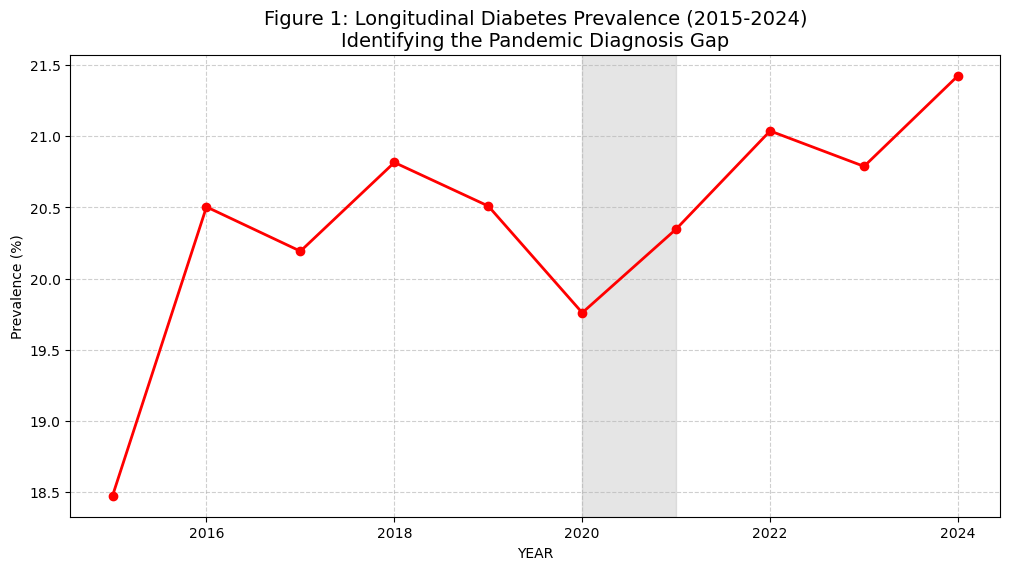

2026-02-04 13:30:06 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

2026-02-04 13:30:07 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


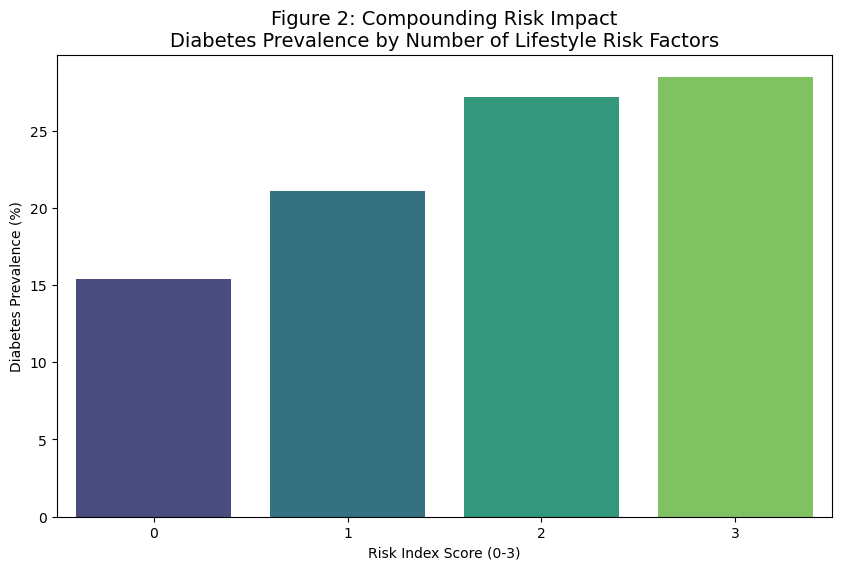

In [7]:
# Load your final harmonized dataset
df = read_zipped_csv(BRFSS_CLEAN_ZIP_FILE)
logging.info(f"Initial data loaded with {df.shape[0]} rows. and columns: {df.shape[1]}")

# --- 1. Pandemic Impact Visualization (RQ2) ---
plt.figure(figsize=(12, 6))
prevalence_by_year = df.groupby('YEAR')['DIABETES'].mean() * 100
ax = prevalence_by_year.plot(kind='line', marker='o', color='red', linewidth=2)
plt.title('Figure 1: Longitudinal Diabetes Prevalence (2015-2024)\nIdentifying the Pandemic Diagnosis Gap', fontsize=14)
plt.ylabel('Prevalence (%)')
plt.grid(True, linestyle='--', alpha=0.6)
# Highlight the pandemic years
plt.axvspan(2020, 2021, color='gray', alpha=0.2, label='COVID-19 Peak')
plt.show()

# --- 2. Compounding Risk Index Visualization (RQ4) ---
# Create the Risk Index: Sum of binary risks (Obesity, Smoking, Inactivity)
df_risk = df.copy()
df_risk['RISK_INDEX'] = (
    (df_risk['BMICAT'] == 3).astype(int)
    + (df_risk['SMOKER'] == 1).astype(int)
    + (df_risk['EXERCISE'] == 1).astype(int)
 )
df_risk['DIABETES_PCT'] = df_risk['DIABETES'] * 100

plt.figure(figsize=(10, 6))
sns.barplot(x='RISK_INDEX', y='DIABETES_PCT', data=df_risk, palette='viridis', estimator=np.mean, errorbar=None)
plt.title('Figure 2: Compounding Risk Impact\nDiabetes Prevalence by Number of Lifestyle Risk Factors', fontsize=14)
plt.ylabel('Diabetes Prevalence (%)')
plt.xlabel('Risk Index Score (0-3)')
plt.show()

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.87      0.86    396523
           1       0.43      0.40      0.42    101395

    accuracy                           0.77    497918
   macro avg       0.64      0.63      0.64    497918
weighted avg       0.77      0.77      0.77    497918

AUPRC Score: 0.41178724686656004


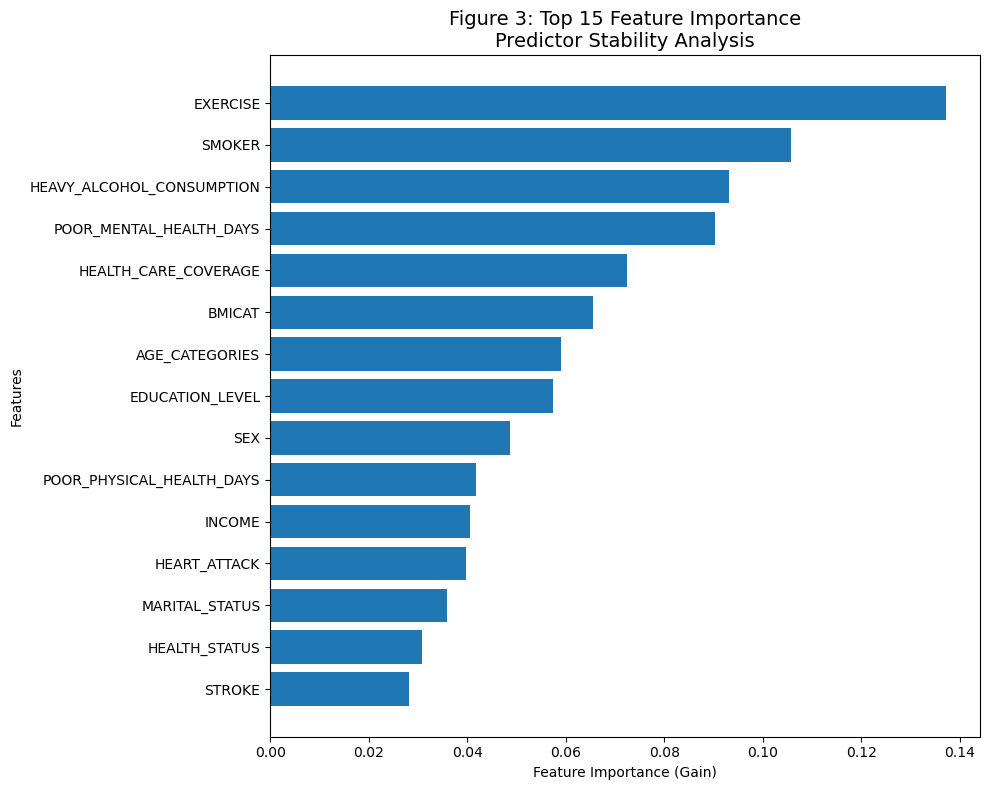


Top 10 Most Important Features:
                      feature  importance
12                   EXERCISE    0.137267
13                     SMOKER    0.105702
14  HEAVY_ALCOHOL_CONSUMPTION    0.093103
17    POOR_MENTAL_HEALTH_DAYS    0.090322
8        HEALTH_CARE_COVERAGE    0.072434
9                      BMICAT    0.065564
1              AGE_CATEGORIES    0.059124
5             EDUCATION_LEVEL    0.057521
2                         SEX    0.048618
16  POOR_PHYSICAL_HEALTH_DAYS    0.041895


In [10]:
# --- 3. Predictive Modeling Pipeline (RQ3) ---

# Ensure DIABETES is binary (0/1)
if df['DIABETES'].dtype == object:
    df['DIABETES'] = df['DIABETES'].replace({
        'Yes': 1, 'No': 0,
        'Diabetes': 1, 'PreDiabetes': 1, 'Gestational': 1,
        'No Diabetes': 0
    })
else:
    df['DIABETES'] = df['DIABETES'].replace({1: 1, 2: 1, 3: 0, 4: 0})

df = df.dropna(subset=['DIABETES'])
df['DIABETES'] = df['DIABETES'].astype(int)

class_counts = df['DIABETES'].value_counts()
if df['DIABETES'].nunique() < 2:
    raise ValueError(f"DIABETES has only one class: {class_counts.to_dict()}. Check source data.")

# Prepare Features (X) and Target (y)
features = [col for col in df.columns if col not in ['DIABETES']]
X = df[features]
y = df['DIABETES']

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
 )

# Apply SMOTE to handle the 85/15 class imbalance
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)

# Initialize and Train XGBoost
model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
model.fit(X_res, y_res)

# Evaluate (Prioritizing Recall and AUPRC)
y_pred = model.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred))
print("AUPRC Score:", average_precision_score(y_test, model.predict_proba(X_test)[:, 1]))

# --- 4. Feature Importance Visualization ---
# Use XGBoost's built-in feature importance as a robust alternative to SHAP
feature_importance = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(feature_importance['feature'].head(15), feature_importance['importance'].head(15))
plt.xlabel('Feature Importance (Gain)')
plt.ylabel('Features')
plt.title('Figure 3: Top 15 Feature Importance\nPredictor Stability Analysis', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10))